# Phase A Load and Profile
## 3.2 Getting Information
Load data.csv with the right encoding. Report shape, and run head(), info(), 
describe(). State which columns have missing values and how many. 

We'll use pandas to read the data from the `.csv` into a dataframe

In [372]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv', encoding='ISO-8859-1')

print(df.shape)
df.info()
df.head()
df.describe()

(541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Print which columns have missing values and how many

In [373]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Description      1454
CustomerID     135080
dtype: int64


## 3.9 Unique Values
Run value_counts() / nunique() on Country, StockCode, Description. Surface non-
product codes and use value_counts(dropna=False) to expose missing entries. 

The raw dataframe is supposed to remain untouched, so we'll create a new one to be cleaned

In [374]:
df_cleaned = pd.read_csv('data.csv', encoding='ISO-8859-1')

# df_cleaned.value_counts(["Country", "StockCode", "Description"])
df_cleaned[["Country", "StockCode", "Description"]].nunique()

Country          38
StockCode      4070
Description    4223
dtype: int64

In [375]:
display(df_cleaned["Country"].value_counts(dropna=False))
display(df_cleaned["StockCode"].value_counts(dropna=False))
display(df_cleaned["Description"].value_counts(dropna=False))

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
          ... 
23609        1
85179a       1
23617        1
90214U       1
47591b       1
Name: count, Length: 4070, dtype: int64

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
                                      ... 
LETTER "U" BLING KEY RING                1
wet                                      1
wet boxes                                1
????damages????                          1
lost                                     1
Name: count, Length: 4224, dtype: int64

## 3.8 Min/Max/Sum/Mean/Count
Summarise Quantity and UnitPrice. Identify the negative quantities (returns) and the 
zero/negative prices that cannot be valid sales. 


In [376]:
display(df_cleaned.describe())
df_cleaned.info()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## 3.1 Creating a Dataframe
Build a small country → region lookup table from a Python dictionary (e.g. United 
Kingdom → UK&IE; France, Germany → Western Europe). You will merge it in later.

In [377]:
# Grabbing all the unique values in the "Country" column
df_cleaned['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [378]:
countryToRegion = {
    "United Kingdom": "UK&IE",
    "France": "Europe",
    "Australia": "Oceania",
    "Netherlands": "Europe",
    "Germany": "Europe",
    "Norway": "Europe",
    "EIRE": "UK&IE",
    "Switzerland": "Europe",
    "Spain": "Europe",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Italy": "Europe",
    "Belgium": "Europe",
    "Lithuania": "Europe",
    "Japan": "Asia",
    "Iceland": "Europe",
    "Channel Islands": "UK&IE",
    "Denmark": "Europe",
    "Cyprus": "Europe",
    "Sweden": "Europe",
    "Israel": "Middle East",
    "Finland": "Europe",
    "Bahrain": "Middle East",
    "Greece": "Europe",
    "Hong Kong": "Asia",
    "Singapore": "Asia",
    "Lebanon": "Middle East",
    "United Arab Emirates": "Middle East",
    "Saudi Arabia": "Middle East",
    "Czech Republic": "Europe",
    "Canada": "North America",
    "Unspecified": "Unspecified",
    "Brazil": "South America",
    "USA": "North America",
    "European Community": "Europe",
    "Malta": "Europe",
    "RSA": "Africa",
}

region_lookup = pd.DataFrame(dict.items(countryToRegion), columns=["Country", "Region"])

region_lookup.head()

,Country,Region
0,United Kingdom,UK&IE
1,France,Europe
2,Australia,Oceania
3,Netherlands,Europe
4,Germany,Europe


# Phase B Select and Filter
## 3.3 Slicing
Inspect row ranges with iloc. Create a unique line-item index and retrieve rows by 
label with loc. 

In [379]:
display(df_cleaned.iloc[0:5])
display(df_cleaned.iloc[100:110])
display(df_cleaned.iloc[1000:1010, 0:5])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
100,536378,84519A,TOMATO CHARLIE+LOLA COASTER SET,6,12/1/2010 9:37,2.95,14688.0,United Kingdom
101,536378,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,48,12/1/2010 9:37,1.25,14688.0,United Kingdom
102,536378,85071B,RED CHARLIE+LOLA PERSONAL DOORSIGN,96,12/1/2010 9:37,0.38,14688.0,United Kingdom
103,536378,21931,JUMBO STORAGE BAG SUKI,10,12/1/2010 9:37,1.95,14688.0,United Kingdom
104,536378,21929,JUMBO BAG PINK VINTAGE PAISLEY,10,12/1/2010 9:37,1.95,14688.0,United Kingdom
105,536380,22961,JAM MAKING SET PRINTED,24,12/1/2010 9:41,1.45,17809.0,United Kingdom
106,536381,22139,RETROSPOT TEA SET CERAMIC 11 PC,23,12/1/2010 9:41,4.25,15311.0,United Kingdom
107,536381,84854,GIRLY PINK TOOL SET,5,12/1/2010 9:41,4.95,15311.0,United Kingdom
108,536381,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,10,12/1/2010 9:41,1.95,15311.0,United Kingdom
109,536381,82567,"AIRLINE LOUNGE,METAL SIGN",2,12/1/2010 9:41,2.10,15311.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate
1000,536520,21123,SET/10 IVORY POLKADOT PARTY CANDLES,1,12/1/2010 12:43
1001,536520,21124,SET/10 BLUE POLKADOT PARTY CANDLES,1,12/1/2010 12:43
1002,536520,21122,SET/10 PINK POLKADOT PARTY CANDLES,1,12/1/2010 12:43
1003,536520,84378,SET OF 3 HEART COOKIE CUTTERS,1,12/1/2010 12:43
1004,536520,21985,PACK OF 12 HEARTS DESIGN TISSUES,12,12/1/2010 12:43
1005,536520,21427,SKULLS STORAGE BOX SMALL,2,12/1/2010 12:43
1006,536520,21034,REX CASH+CARRY JUMBO SHOPPER,2,12/1/2010 12:43
1007,536520,21930,JUMBO STORAGE BAG SKULLS,1,12/1/2010 12:43
1008,536520,20772,GARDEN PATH JOURNAL,1,12/1/2010 12:43
1009,536520,22469,HEART OF WICKER SMALL,2,12/1/2010 12:43


In [380]:
df_cleaned['unique_id'] = (df_cleaned['InvoiceNo'].astype(str) + '_' +
                           df_cleaned['StockCode'].astype(str) + '_' +
                           df_cleaned.groupby(['InvoiceNo','StockCode']).cumcount().astype(str))
display(df_cleaned.head())

df_cleaned.loc[df_cleaned['unique_id'] == '536365_85123A_0']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,unique_id
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,536365_85123A_0
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365_71053_0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,536365_84406B_0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365_84029G_0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365_84029E_0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,unique_id
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,536365_85123A_0


## 3.4 Conditional Selection
Isolate cancellations (InvoiceNo starts with 'C'), rows where Quantity <= 0, and rows where UnitPrice <= 0. Count each group. 

In [381]:
# Determine number of cancelled orders
df_cleaned[df_cleaned['InvoiceNo'].str.startswith('C')].shape[0]

9288

In [382]:
# Number of rows with invalid quantities (negative values or zero)
df_cleaned[(df_cleaned['Quantity'] <= 0)].shape[0]

10624

In [383]:
# Number of entries with invalid unit prices (negative values or zero)
df_cleaned[(df_cleaned['UnitPrice'] <= 0)].shape[0]

2517

## 3.5 Sorting Values
Sort by Quantity and by line revenue to find the largest bulk orders and the largest 
returns.

In [384]:
# Find orders with largest quantities
df_cleaned.sort_values(by=['Quantity'], inplace=True, ascending=False)
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,unique_id
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,581483_23843_0
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,541431_23166_0
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,11/25/2011 15:57,0.00,13256.0,United Kingdom,578841_84826_0
74614,542504,37413,NaN,5568,1/28/2011 12:03,0.00,NaN,United Kingdom,542504_37413_0
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,10/27/2011 12:26,0.21,12901.0,United Kingdom,573008_84077_0


In [385]:
# Find orders with largest line revenue
df_cleaned['LineRevenue'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']
df_cleaned.sort_values(by=['LineRevenue'], inplace=True, ascending=False)
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,unique_id,LineRevenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,581483_23843_0,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,541431_23166_0,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,6/10/2011 15:28,649.50,15098.0,United Kingdom,556444_22502_0,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,12/7/2010 15:08,13541.33,NaN,United Kingdom,537632_AMAZONFEE_0,13541.33
299982,A563185,B,Adjust bad debt,1,8/12/2011 14:50,11062.06,NaN,United Kingdom,A563185_B_0,11062.06


# Phase C Clean & Fix
## 3.6 Replacing Values
Standardise country labels: 'EIRE' → 'Ireland', 'RSA' → 'South Africa','Unspecified' → missing.

In [386]:
countryStandardizationMap = {
    "EIRE":"Ireland",
    "RSA":"South Africa",
    "Unspecified": np.nan
}
df_cleaned['Country'] = df_cleaned["Country"].replace(countryStandardizationMap)
display(df_cleaned['Country'].unique())

<StringArray>
[      'United Kingdom',          'Netherlands',               'France',
            'Singapore',                'Japan',            'Hong Kong',
              'Ireland',            'Australia',                'Spain',
             'Portugal',               'Sweden',              'Germany',
               'Norway',              'Finland',               'Canada',
                'Malta',              'Denmark',      'Channel Islands',
              'Austria',          'Switzerland',               'Israel',
               'Cyprus',                'Italy',              'Iceland',
              'Bahrain',               'Greece',               'Brazil',
              'Belgium', 'United Arab Emirates',              'Lebanon',
            'Lithuania',               'Poland',                  'USA',
       'Czech Republic',                    nan,   'European Community',
         'South Africa',         'Saudi Arabia']
Length: 38, dtype: str

## 3.7 Renaming Columns
Rename all columns to snake_case (InvoiceNo → invoice_no, UnitPrice → 
unit_price, ...). 

In [387]:
# rename columns to snake_case
df_cleaned.rename(columns={
    'InvoiceNo': 'invoice_no',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'UnitPrice': 'unit_price',
    'CustomerID': 'customer_id',
    'Country': 'country',
    'LineRevenue': 'line_revenue'
}, inplace=True)

df_cleaned.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,unique_id,line_revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,581483_23843_0,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,541431_23166_0,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,6/10/2011 15:28,649.50,15098.0,United Kingdom,556444_22502_0,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,12/7/2010 15:08,13541.33,NaN,United Kingdom,537632_AMAZONFEE_0,13541.33
299982,A563185,B,Adjust bad debt,1,8/12/2011 14:50,11062.06,NaN,United Kingdom,A563185_B_0,11062.06


## 3.10 Handle Missing Values
Quantify missingness, then decide and justify a policy for missing CustomerID and 
blank Description. Demonstrate isnull(), dropna(), fillna(). 

In [388]:
missing_values_cleaned = df_cleaned.isnull().sum()

print(missing_values_cleaned[missing_values_cleaned > 0])

description      1454
customer_id    135080
country           446
dtype: int64


In [389]:
#Get a sample of null values in the customer_id column
df_cleaned[df_cleaned['customer_id'].isnull()].head(20)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,unique_id,line_revenue
15017,537632,AMAZONFEE,AMAZON FEE,1,12/7/2010 15:08,13541.33,NaN,United Kingdom,537632_AMAZONFEE_0,13541.33
299982,A563185,B,Adjust bad debt,1,8/12/2011 14:50,11062.06,NaN,United Kingdom,A563185_B_0,11062.06
467804,576365,22086,PAPER CHAIN KIT 50'S CHRISTMAS,688,11/14/2011 17:55,6.95,NaN,United Kingdom,576365_22086_0,4781.60
297723,562955,DOT,DOTCOM POSTAGE,1,8/11/2011 10:14,4505.17,NaN,United Kingdom,562955_DOT_0,4505.17
268028,560373,M,Manual,1,7/18/2011 12:30,4287.63,NaN,United Kingdom,560373_M_0,4287.63
447035,574941,22197,POPCORN HOLDER,1820,11/7/2011 17:42,1.95,NaN,United Kingdom,574941_22197_0,3549.00
447040,574941,22086,PAPER CHAIN KIT 50'S CHRISTMAS,478,11/7/2011 17:42,6.95,NaN,United Kingdom,574941_22086_0,3322.10
447007,574941,23084,RABBIT NIGHT LIGHT,628,11/7/2011 17:42,4.95,NaN,United Kingdom,574941_23084_0,3108.60
347948,567353,M,Manual,1,9/19/2011 16:14,2653.95,NaN,Hong Kong,567353_M_0,2653.95
247994,558777,22501,PICNIC BASKET WICKER LARGE,125,7/4/2011 10:23,20.79,NaN,United Kingdom,558777_22501_0,2598.75


In [390]:
# Get a sample of null values in the description column
df_cleaned[df_cleaned['description'].isnull()].head(20)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,unique_id,line_revenue
150158,549348,84251B,NaN,-60,4/8/2011 11:13,0.0,NaN,United Kingdom,549348_84251B_0,-0.0
29972,538837,85135B,NaN,-40,12/14/2010 13:10,0.0,NaN,United Kingdom,538837_85135B_0,-0.0
178019,552225,22775,NaN,-40,5/6/2011 15:26,0.0,NaN,United Kingdom,552225_22775_0,-0.0
264704,560110,21673,NaN,-40,7/15/2011 9:51,0.0,NaN,United Kingdom,560110_21673_0,-0.0
201551,554299,20975,NaN,-39,5/23/2011 14:28,0.0,NaN,United Kingdom,554299_20975_0,-0.0
43704,540119,22865,NaN,-60,1/5/2011 10:07,0.0,NaN,United Kingdom,540119_22865_0,-0.0
280661,561484,77081,NaN,-39,7/27/2011 13:41,0.0,NaN,United Kingdom,561484_77081_0,-0.0
320594,565052,21179,NaN,-60,8/31/2011 17:11,0.0,NaN,United Kingdom,565052_21179_0,-0.0
242057,558307,22088,NaN,-39,6/28/2011 11:02,0.0,NaN,United Kingdom,558307_22088_0,-0.0
143342,548693,22720,NaN,-60,4/1/2011 17:25,0.0,NaN,United Kingdom,548693_22720_0,-0.0


For line items with missing descriptions, we first try to recover the description from another item with the same stock code, if that fails, then we discard the remainder since it is likely that was not an actually sellable item

In [391]:
# Try to recover missing descriptions from other rows sharing the same stock_code.
# Use the most common (mode) description per stock_code so one-off data-entry noise
# (e.g. "damaged", "?", "wrongly coded") can't outweigh the real product name.
code_to_description_map = (
    df_cleaned.dropna(subset=['description'])
    .groupby('stock_code')['description']
    .agg(lambda s: s.mode()[0])
    .to_dict()
)
df_cleaned['description'] = df_cleaned['description'].fillna(df_cleaned['stock_code'].map(code_to_description_map))

# Check if there are still any missing values in the description column
missing_values_cleaned_after = df_cleaned.isnull().sum()
missing_values_cleaned_after[missing_values_cleaned_after > 0]

description       112
customer_id    135080
country           446
dtype: int64

Now there are only 112 line items with missing values, rather than 1454, we'll drop the remainder

In [392]:
df_cleaned = df_cleaned.dropna(subset=['description'])

For missing customer IDs, it doesn't necessarily indicate that there wasn't a sale there, just that the customer was anonymous or unrecorded. For revenue-related questions, we can keep the no-customer ID data, but for analyses that require information about the customers we'll discard the no-ID data

## 3.11 Dropping a Column

Drop a column you will not use in the final analysis and explain why.

`unique_id` was only useful for demonstrating slicing and can be removed at the end

## 3.12 Deleting a Row
Remove cancellations, non-product lines, and impossible prices/quantities to build a 
clean sales DataFrame. 

In [393]:
# Remove cancelled orders and orders with invalid quantities or unit prices
df_cleaned = df_cleaned[~df_cleaned['invoice_no'].str.startswith('C')]
df_cleaned = df_cleaned[df_cleaned['quantity'] > 0]
df_cleaned = df_cleaned[df_cleaned['unit_price'] > 0]

# Non-product codes: postage, fees, commissions, manual adjustments, bad debt
non_product_codes = ['POST', 'DOT', 'M', 'm', 'C2', 'D', 'S',
                     'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'B']

df_cleaned = df_cleaned[~df_cleaned['stock_code'].isin(non_product_codes)]

# Gift vouchers are store credit so they don't contribute revenue
df_cleaned = df_cleaned[~df_cleaned['stock_code'].str.startswith('gift_')]


## 3.13 Dropping Duplicates
Detect exact duplicates with duplicated().sum() and remove them with 
drop_duplicates(). Report how many rows were dropped. 

In [394]:
# Display exact duplicates

#Make sure the UID column is not counted
business_cols = ['invoice_no', 'stock_code', 'description', 'quantity',
                 'unit_price', 'customer_id', 'country']
display(df_cleaned[business_cols].duplicated().sum())

num_before_dedup = len(df_cleaned)

df_cleaned = df_cleaned.drop_duplicates(subset=business_cols, keep='first')
print(f"Removed {num_before_dedup - len(df_cleaned)} duplicate rows.")

display(df_cleaned.head())

np.int64(5222)

Removed 5222 duplicate rows.


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,unique_id,line_revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,581483_23843_0,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,541431_23166_0,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,6/10/2011 15:28,649.50,15098.0,United Kingdom,556444_22502_0,38970.00
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,9/20/2011 11:05,5.06,17450.0,United Kingdom,567423_23243_0,7144.72
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,4/18/2011 13:20,2.10,15749.0,United Kingdom,550461_21108_0,6539.40


# Phase D Engineer and Summarize
## 3.18 Applying a Function
Add a revenue = quantity * unit_price column. Use apply to clean Description (strip 
+ title-case) and to flag cancelled invoices.

I did the revenue calculation in 3.5, we also removed the cancelled invoices in 3.12, I can demonstrate adding the flag by doing it on another copy of the original dataset


In [395]:
df_cleaned['description'] = df_cleaned['description'].apply(lambda x: x.strip().title())

display(df_cleaned.head())

df_cancelled_copy = df.copy()
df_cancelled_copy['cancel_flag'] = df_cancelled_copy['InvoiceNo'].str.startswith('C')
display(df_cancelled_copy.head())


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,unique_id,line_revenue
540421,581483,23843,"Paper Craft , Little Birdie",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,581483_23843_0,168469.60
61619,541431,23166,Medium Ceramic Top Storage Jar,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,541431_23166_0,77183.60
222680,556444,22502,Picnic Basket Wicker 60 Pieces,60,6/10/2011 15:28,649.50,15098.0,United Kingdom,556444_22502_0,38970.00
348325,567423,23243,Set Of Tea Coffee Sugar Tins Pantry,1412,9/20/2011 11:05,5.06,17450.0,United Kingdom,567423_23243_0,7144.72
160546,550461,21108,Fairy Cake Flannel Assorted Colour,3114,4/18/2011 13:20,2.10,15749.0,United Kingdom,550461_21108_0,6539.40


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,cancel_flag
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,False


## 3.17 Looping Over a Column
Show a for-loop / list comprehension over a column, then explain why apply is the
preferred, faster approach.

In [396]:
# Description stripping and title-casing using a for loop instead of apply
for i in range(len(df_cleaned)):
    df_cleaned.iloc[i, df_cleaned.columns.get_loc('description')] = df_cleaned.iloc[i, df_cleaned.columns.get_loc('description')].strip().title()

display(df_cleaned.head())

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,unique_id,line_revenue
540421,581483,23843,"Paper Craft , Little Birdie",80995,12/9/2011 9:15,2.08,16446.0,United Kingdom,581483_23843_0,168469.60
61619,541431,23166,Medium Ceramic Top Storage Jar,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom,541431_23166_0,77183.60
222680,556444,22502,Picnic Basket Wicker 60 Pieces,60,6/10/2011 15:28,649.50,15098.0,United Kingdom,556444_22502_0,38970.00
348325,567423,23243,Set Of Tea Coffee Sugar Tins Pantry,1412,9/20/2011 11:05,5.06,17450.0,United Kingdom,567423_23243_0,7144.72
160546,550461,21108,Fairy Cake Flannel Assorted Colour,3114,4/18/2011 13:20,2.10,15749.0,United Kingdom,550461_21108_0,6539.40


Apply is prefered since it can use pandas internal C-compiled code, whereas a for loop has to be interpreted by python on every iteration. On my machine apply-based code ran in 0.0 seconds whereas the for loop took 14.2 seconds

## 3.14 Grouping by Values
Use groupby to compute revenue by Country and number of orders per customer.

In [397]:
revenue_per_country = df_cleaned.groupby('country')['line_revenue'].sum().sort_values(ascending=False)
display(revenue_per_country)

country
United Kingdom          8724439.773
Netherlands              283889.340
Ireland                  270850.860
Germany                  205381.150
France                   184493.000
Australia                138103.810
Spain                     55706.560
Switzerland               53065.600
Japan                     37416.370
Belgium                   36927.340
Sweden                    36828.830
Norway                    32454.640
Portugal                  26951.110
Channel Islands           19997.540
Finland                   18344.880
Denmark                   18211.340
Italy                     15820.240
Cyprus                    13167.160
Hong Kong                  9744.190
Singapore                  9120.390
Austria                    8742.680
Israel                     8129.410
Poland                     6974.650
Greece                     4425.520
Iceland                    4310.000
USA                        3580.390
Canada                     3115.440
Malta               

In [398]:
orders_per_customer = df_cleaned.groupby('customer_id')['invoice_no'].nunique().sort_values(ascending=False)
display(orders_per_customer)

customer_id
12748.0    206
14911.0    198
17841.0    124
13089.0     97
15311.0     91
          ... 
16222.0      1
13751.0      1
13753.0      1
16216.0      1
12346.0      1
Name: invoice_no, Length: 4334, dtype: int64

## 3.16 Aggregating
Use agg to produce several statistics at once (total revenue, mean order value,
transaction count) per country and per customer.

In [399]:
stats_per_country = df_cleaned.groupby('country').agg(
    total_revenue=('line_revenue', 'sum'),
    mean_order_value=('line_revenue', 'mean'),
    total_orders=('invoice_no', 'nunique')
).sort_values(by='total_revenue', ascending=False)
display(stats_per_country)

,total_revenue,mean_order_value,total_orders
country,,,
United Kingdom,8724439.773,18.218692,17901
Netherlands,283889.340,122.260698,93
Ireland,270850.860,34.867515,282
Germany,205381.150,23.762715,443
France,184493.000,22.819171,382
Australia,138103.810,117.037127,56
Spain,55706.560,23.047811,88
Switzerland,53065.600,27.537935,50
Japan,37416.370,116.561900,19


In [400]:
stats_per_customer = df_cleaned.dropna(subset=['customer_id']).groupby('customer_id').agg(
    total_revenue=('line_revenue', 'sum'),
    mean_order_value=('line_revenue', 'mean'),
    total_orders=('invoice_no', 'nunique')
).sort_values(by='total_revenue', ascending=False)
display(stats_per_customer)

,total_revenue,mean_order_value,total_orders
customer_id,,,
14646.0,279138.02,135.503893,72
18102.0,259657.30,602.453132,60
17450.0,194390.79,578.544018,46
16446.0,168472.50,56157.500000,2
14911.0,136161.83,24.384282,198
...,...,...,...
16878.0,13.30,4.433333,1
17956.0,12.75,12.750000,1
14792.0,6.20,3.100000,1


## 3.19 Applying to Groups
Use groupby(...).apply(...) for a custom per-customer summary (e.g. total spend and
number of active months).

assuming that active months is the number of months in which they made a purchase, rather than how long the account has been open

In [401]:
df_cleaned['invoice_date'] = pd.to_datetime(df_cleaned['invoice_date'])
def customer_summary(group):
    return pd.Series({
        'total_spend': group['line_revenue'].sum(),
        'num_active_months': group['invoice_date'].dt.to_period('M').nunique()
    })

summary_per_customer = df_cleaned.dropna(subset=['customer_id']).groupby('customer_id').apply(customer_summary)
display(summary_per_customer.head())
display(summary_per_customer.head().sort_values(by='num_active_months', ascending=False).head(10))

,total_spend,num_active_months
customer_id,,
12346.0,77183.60,1.0
12347.0,4310.00,7.0
12348.0,1437.24,4.0
12349.0,1457.55,1.0
12350.0,294.40,1.0


,total_spend,num_active_months
customer_id,,
12347.0,4310.00,7.0
12348.0,1437.24,4.0
12346.0,77183.60,1.0
12349.0,1457.55,1.0
12350.0,294.40,1.0


## 3.15 Grouping by Time
Parse InvoiceDate to datetime, set it as the index, and resample monthly/weekly to
chart the revenue trend.

In [402]:
#Did the first part in 3.19 already
df_cleaned.set_index('invoice_date', inplace=True)

display(df_cleaned.sort_index().head(10))

,invoice_no,stock_code,description,quantity,unit_price,customer_id,country,unique_id,line_revenue
invoice_date,,,,,,,,,
2010-12-01 08:26:00,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,17850.0,United Kingdom,536365_84406B_0,22.00
2010-12-01 08:26:00,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,17850.0,United Kingdom,536365_85123A_0,15.30
2010-12-01 08:26:00,536365,84029G,Knitted Union Flag Hot Water Bottle,6,3.39,17850.0,United Kingdom,536365_84029G_0,20.34
2010-12-01 08:26:00,536365,84029E,Red Woolly Hottie White Heart.,6,3.39,17850.0,United Kingdom,536365_84029E_0,20.34
2010-12-01 08:26:00,536365,22752,Set 7 Babushka Nesting Boxes,2,7.65,17850.0,United Kingdom,536365_22752_0,15.30
2010-12-01 08:26:00,536365,71053,White Metal Lantern,6,3.39,17850.0,United Kingdom,536365_71053_0,20.34
2010-12-01 08:26:00,536365,21730,Glass Star Frosted T-Light Holder,6,4.25,17850.0,United Kingdom,536365_21730_0,25.50
2010-12-01 08:28:00,536366,22632,Hand Warmer Red Polka Dot,6,1.85,17850.0,United Kingdom,536366_22632_0,11.10
2010-12-01 08:28:00,536366,22633,Hand Warmer Union Jack,6,1.85,17850.0,United Kingdom,536366_22633_0,11.10


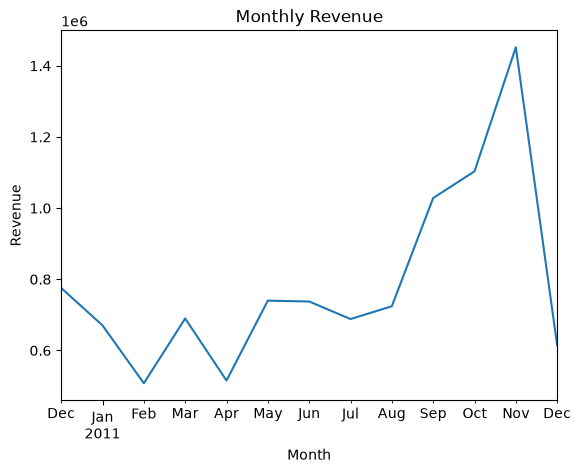

In [403]:
monthly_revenue = df_cleaned['line_revenue'].resample('ME').sum()

monthly_revenue.plot(title='Monthly Revenue', xlabel='Month', ylabel='Revenue')
plt.show()

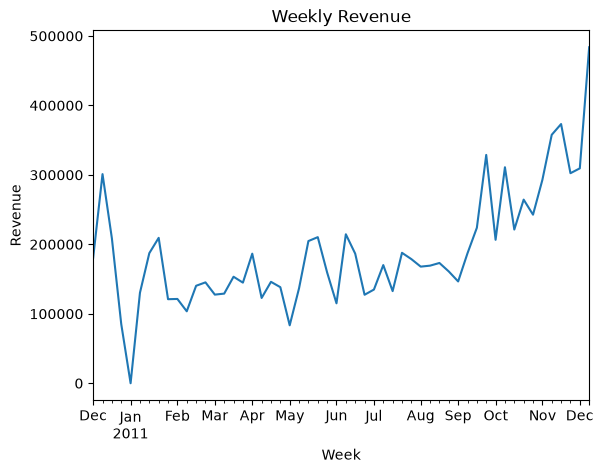

In [404]:
weekly_revenue = df_cleaned['line_revenue'].resample('W').sum()

weekly_revenue.plot(title='Weekly Revenue', xlabel='Week', ylabel='Revenue')
plt.show()

# Phase E Combine
## 3.20 Concatenating
Split your clean data into two periods (first vs second half of the year) and concat
them back — simulating the merge of two monthly extracts.

In [405]:
cutoff_date = pd.Timestamp('2011-06-30')
first_half_year_df = df_cleaned[df_cleaned.index < cutoff_date]
second_half_year_df = df_cleaned[df_cleaned.index >= cutoff_date]

display(first_half_year_df.head())
display(second_half_year_df.head())

,invoice_no,stock_code,description,quantity,unit_price,customer_id,country,unique_id,line_revenue
invoice_date,,,,,,,,,
2011-01-18 10:01:00,541431,23166,Medium Ceramic Top Storage Jar,74215,1.04,12346.0,United Kingdom,541431_23166_0,77183.6
2011-06-10 15:28:00,556444,22502,Picnic Basket Wicker 60 Pieces,60,649.50,15098.0,United Kingdom,556444_22502_0,38970.0
2011-04-18 13:20:00,550461,21108,Fairy Cake Flannel Assorted Colour,3114,2.10,15749.0,United Kingdom,550461_21108_0,6539.4
2011-01-11 12:55:00,540815,21108,Fairy Cake Flannel Assorted Colour,3114,2.10,15749.0,United Kingdom,540815_21108_0,6539.4
2011-01-11 12:55:00,540815,85123A,White Hanging Heart T-Light Holder,1930,2.55,15749.0,United Kingdom,540815_85123A_0,4921.5


,invoice_no,stock_code,description,quantity,unit_price,customer_id,country,unique_id,line_revenue
invoice_date,,,,,,,,,
2011-12-09 09:15:00,581483,23843,"Paper Craft , Little Birdie",80995,2.08,16446.0,United Kingdom,581483_23843_0,168469.60
2011-09-20 11:05:00,567423,23243,Set Of Tea Coffee Sugar Tins Pantry,1412,5.06,17450.0,United Kingdom,567423_23243_0,7144.72
2011-10-27 12:11:00,573003,23084,Rabbit Night Light,2400,2.08,14646.0,Netherlands,573003_23084_0,4992.00
2011-11-14 17:55:00,576365,22086,Paper Chain Kit 50'S Christmas,688,6.95,NaN,United Kingdom,576365_22086_0,4781.60
2011-06-30 11:01:00,558526,23173,Regency Teapot Roses,540,8.15,17949.0,United Kingdom,558526_23173_0,4401.00


In [406]:
full_year_df = pd.concat([first_half_year_df, second_half_year_df])

display(full_year_df.head())

,invoice_no,stock_code,description,quantity,unit_price,customer_id,country,unique_id,line_revenue
invoice_date,,,,,,,,,
2011-01-18 10:01:00,541431,23166,Medium Ceramic Top Storage Jar,74215,1.04,12346.0,United Kingdom,541431_23166_0,77183.6
2011-06-10 15:28:00,556444,22502,Picnic Basket Wicker 60 Pieces,60,649.50,15098.0,United Kingdom,556444_22502_0,38970.0
2011-04-18 13:20:00,550461,21108,Fairy Cake Flannel Assorted Colour,3114,2.10,15749.0,United Kingdom,550461_21108_0,6539.4
2011-01-11 12:55:00,540815,21108,Fairy Cake Flannel Assorted Colour,3114,2.10,15749.0,United Kingdom,540815_21108_0,6539.4
2011-01-11 12:55:00,540815,85123A,White Hanging Heart T-Light Holder,1930,2.55,15749.0,United Kingdom,540815_85123A_0,4921.5


In [407]:
#Verify we didn't lose any rows in the concatenation
assert len(full_year_df) == len(df_cleaned), "Row count mismatch after concatenation"

## 3.21 Merging
Use merge to add a region column from your lookup. Compare inner vs left joins and
note which countries fail to match.

In [408]:
#Takes the region map that we created earlier
merged_left = df_cleaned.merge(region_lookup, how="left", left_on="country", right_on="Country")
merged_inner = df_cleaned.merge(region_lookup, how="inner", left_on="country", right_on="Country")

display(merged_left.info())
display(merged_inner.info())

<class 'pandas.DataFrame'>
RangeIndex: 522539 entries, 0 to 522538
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_no    522539 non-null  str    
 1   stock_code    522539 non-null  str    
 2   description   522539 non-null  str    
 3   quantity      522539 non-null  int64  
 4   unit_price    522539 non-null  float64
 5   customer_id   391152 non-null  float64
 6   country       522097 non-null  str    
 7   unique_id     522539 non-null  str    
 8   line_revenue  522539 non-null  float64
 9   Country       513888 non-null  str    
 10  Region        513888 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 43.9 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 513888 entries, 0 to 513887
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_no    513888 non-null  str    
 1   stock_code    513888 non-null  str    
 2   description   513888 non-null  str    
 3   quantity      513888 non-null  int64  
 4   unit_price    513888 non-null  float64
 5   customer_id   383344 non-null  float64
 6   country       513888 non-null  str    
 7   unique_id     513888 non-null  str    
 8   line_revenue  513888 non-null  float64
 9   Country       513888 non-null  str    
 10  Region        513888 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 43.1 MB


None

The inner merge now has fewer entries, since any entry with an unspecified country (changed to NaN) got dropped by the inner join.

# Part 2 Answer the Business Questions
Using your cleaned, completed-sales dataset, answer each question with code, a number
or short table, and one or two sentences of interpretation a non-technical manager
could follow.

## 1. Seasonality
What was total revenue for the year, and how does it break down by month? When is the
peak trading season, and by how much does it lift sales?

Total Revenue: 10,247,215.42


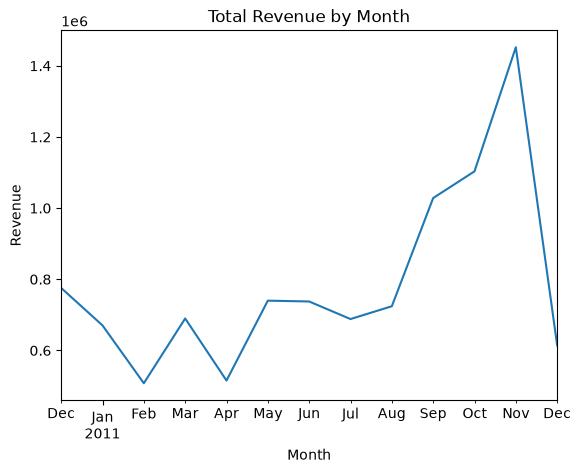

Average Revenue by Month: 788,247.34
Month with highest revenue: November 2011 with revenue of 1,452,115.98
Maximum Trading Season Boost: 84.22%


In [409]:
total_revenue = df_cleaned['line_revenue'].sum()
print(f"Total Revenue: {total_revenue:,.2f}")

total_revenue_by_month = df_cleaned['line_revenue'].resample('ME').sum()
total_revenue_by_month.plot(title='Total Revenue by Month', xlabel='Month', ylabel='Revenue')
plt.savefig('total_revenue_by_month.png')
plt.show()

average_revenue_by_month = df_cleaned['line_revenue'].resample('ME').sum().mean()
maximum_revenue_by_month = df_cleaned['line_revenue'].resample('ME').sum().max()
max_trading_season_boost = (maximum_revenue_by_month - average_revenue_by_month) / average_revenue_by_month * 100
print(f"Average Revenue by Month: {average_revenue_by_month.mean():,.2f}")
month_with_highest_revenue = total_revenue_by_month.idxmax()
print(f"Month with highest revenue: {month_with_highest_revenue.strftime('%B %Y')} with revenue of {total_revenue_by_month.max():,.2f}")

print(f"Maximum Trading Season Boost: {max_trading_season_boost.max():.2f}%")

The total revenue for the 2010-2011 fiscal year was £10,247,219.32. The highest trading month was November, with £1,452,115.98 sales, 84% higher than a typical month. This corresponds with the run up to the holiday season.

## 2. Best Sellers
Which 10 products earned the most revenue, and which 10 sold the most units? Are they
the same list and what does any difference tell you about pricing?

In [410]:
# Aggregate revenue, units, and price per product
product_stats = df_cleaned.groupby('description').agg(
    revenue=('line_revenue', 'sum'),
    units=('quantity', 'sum'),
).round(2)
# Effective price = volume-weighted price actually realised per unit
product_stats['effective_price'] = (product_stats['revenue'] / product_stats['units']).round(2)

top_by_revenue = product_stats.sort_values('revenue', ascending=False).head(10)
top_by_units   = product_stats.sort_values('units', ascending=False).head(10)

print("Top 10 products by revenue:")
display(top_by_revenue)
print("Top 10 products by units sold:")
display(top_by_units)

# Overlap analysis
rev_set   = set(top_by_revenue.index)
units_set = set(top_by_units.index)

in_both      = rev_set & units_set
revenue_only = rev_set - units_set
units_only   = units_set - rev_set

# Combined summary table with price
all_products = sorted(rev_set | units_set)
summary = product_stats.loc[all_products].copy()
summary['category'] = summary.index.map(
    lambda p: 'both' if p in in_both else ('revenue-only' if p in revenue_only else 'units-only')
)
display(summary.sort_values('revenue', ascending=False))

Top 10 products by revenue:


,revenue,units,effective_price
description,,,
Regency Cakestand 3 Tier,174156.54,13851,12.57
"Paper Craft , Little Birdie",168469.60,80995,2.08
White Hanging Heart T-Light Holder,106236.72,37872,2.81
Party Bunting,99445.23,18283,5.44
Jumbo Bag Red Retrospot,94159.81,48371,1.95
Medium Ceramic Top Storage Jar,81700.92,78033,1.05
Rabbit Night Light,66870.03,30739,2.18
Paper Chain Kit 50'S Christmas,64875.59,19329,3.36
Assorted Colour Bird Ornament,58927.62,36362,1.62


Top 10 products by units sold:


,revenue,units,effective_price
description,,,
"Paper Craft , Little Birdie",168469.60,80995,2.08
Medium Ceramic Top Storage Jar,81700.92,78033,1.05
World War 2 Gliders Asstd Designs,13814.01,54951,0.25
Jumbo Bag Red Retrospot,94159.81,48371,1.95
White Hanging Heart T-Light Holder,106236.72,37872,2.81
Popcorn Holder,34288.67,36749,0.93
Pack Of 72 Retrospot Cake Cases,21246.45,36396,0.58
Assorted Colour Bird Ornament,58927.62,36362,1.62
Rabbit Night Light,66870.03,30739,2.18


,revenue,units,effective_price,category
description,,,,
Regency Cakestand 3 Tier,174156.54,13851,12.57,revenue-only
"Paper Craft , Little Birdie",168469.60,80995,2.08,both
White Hanging Heart T-Light Holder,106236.72,37872,2.81,both
Party Bunting,99445.23,18283,5.44,revenue-only
Jumbo Bag Red Retrospot,94159.81,48371,1.95,both
Medium Ceramic Top Storage Jar,81700.92,78033,1.05,both
Rabbit Night Light,66870.03,30739,2.18,both
Paper Chain Kit 50'S Christmas,64875.59,19329,3.36,revenue-only
Assorted Colour Bird Ornament,58927.62,36362,1.62,both


Of the top 10 items sold by revenue, 6 of them are also in the top 10 by quantity sold. The best sellers are typically made up of low-price, high volume sales.

## 3. Markets
Outside the UK, which countries (and which regions, using your merged lookup) are
most valuable by revenue and by number of distinct customers? Where would you expand?

In [411]:
revenue_by_country = df_cleaned.groupby('country')['line_revenue'].sum().sort_values(ascending=False)
display(revenue_by_country.head(10))

num_customers_by_country = df_cleaned.groupby('country')['customer_id'].nunique().sort_values(ascending=False)
display(num_customers_by_country.head(10))

value_per_customer_by_country = revenue_by_country / num_customers_by_country
display(value_per_customer_by_country.sort_values(ascending=False).head(10))

country
United Kingdom    8724439.773
Netherlands        283889.340
Ireland            270850.860
Germany            205381.150
France             184493.000
Australia          138103.810
Spain               55706.560
Switzerland         53065.600
Japan               37416.370
Belgium             36927.340
Name: line_revenue, dtype: float64

country
United Kingdom    3916
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: customer_id, dtype: int64

country
Hong Kong               inf
Ireland        9.028362e+04
Netherlands    3.154326e+04
Australia      1.534487e+04
Singapore      9.120390e+03
Japan          4.677046e+03
Sweden         4.603604e+03
Iceland        4.310000e+03
Norway         3.245464e+03
Israel         2.709803e+03
dtype: float64

The data here suggests that expansion into Ireland would be most prudent, as they tend to spend the most money per customer.

In [412]:
# Use the inner join to ensure we only count customers with a valid region
revenue_by_region = merged_inner.groupby('Region')['line_revenue'].sum().sort_values(ascending=False)
display(revenue_by_region)

num_customers_by_region = merged_inner.groupby('Region')['customer_id'].nunique().sort_values(ascending=False)
display(num_customers_by_region)

value_per_customer_by_region = revenue_by_region / num_customers_by_region
display(value_per_customer_by_region.sort_values(ascending=False))

Region
UK&IE            8744437.313
Europe           1002629.000
Oceania           138103.810
Asia               56280.950
Middle East        12588.130
North America       6695.830
South America       1143.600
Name: line_revenue, dtype: float64

Region
UK&IE            3925
Europe            358
Asia                9
Middle East         9
Oceania             9
North America       8
South America       1
Name: customer_id, dtype: int64

Region
Oceania          15344.867778
Asia              6253.438889
Europe            2800.639665
UK&IE             2227.882118
Middle East       1398.681111
South America     1143.600000
North America      836.978750
dtype: float64

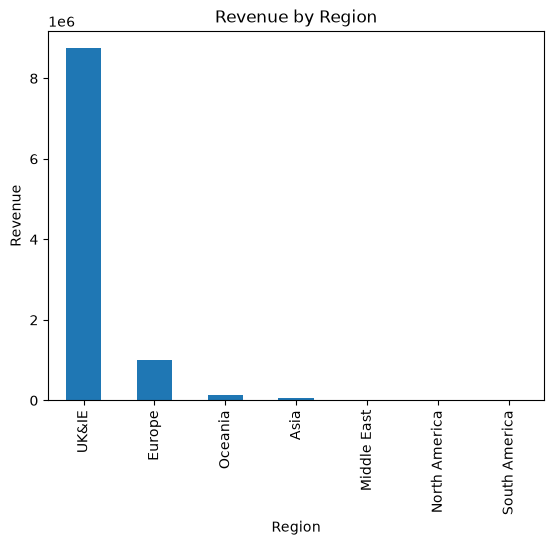

In [420]:
revenue_by_region.plot(kind='bar', title='Revenue by Region', xlabel='Region', ylabel='Revenue')
plt.savefig('revenue_by_region.png')
plt.show()

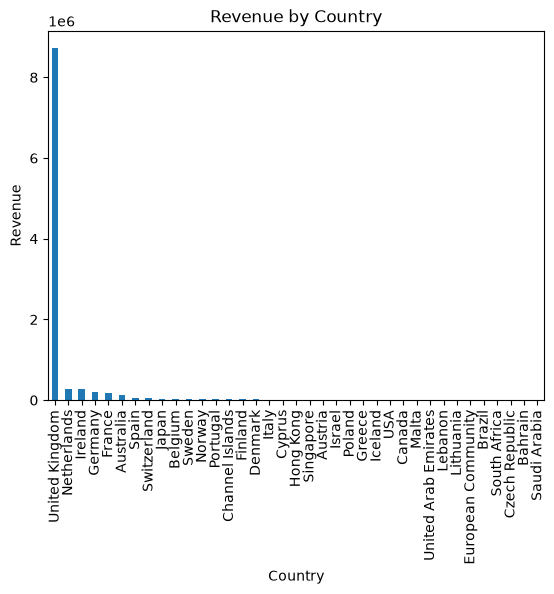

In [414]:
revenue_by_country.plot(kind='bar', title='Revenue by Country', xlabel='Country', ylabel='Revenue')
plt.show()

The most value per customer comes from the Oceania and Asia regions, however, the proximity of the European region would provide the third highest value per customer, without the large costs of global expansion

## 4. Customer Concentration
Who are the top 10 customers by total spend, and what share of total revenue do the
top 1% of customers account for? Is this a wholesale-driven business?

In [415]:
customers_by_revenue = df_cleaned.groupby('customer_id')['line_revenue'].sum().sort_values(ascending=False)
display(customers_by_revenue.head(10))

top_1_percent_revenue_share = customers_by_revenue.nlargest(int(len(customers_by_revenue) * 0.01)).sum() / customers_by_revenue.sum()
print(f"Top 1% of customers account for {top_1_percent_revenue_share:.2%} of total revenue.")

customer_id
14646.0    279138.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    136161.83
12415.0    124564.53
14156.0    116560.08
17511.0     91062.38
12346.0     77183.60
16029.0     72708.09
Name: line_revenue, dtype: float64

Top 1% of customers account for 31.99% of total revenue.


This appears to be a wholesale driven business

## 5. Order Value
What is the average order value (revenue per invoice), and how does it differ between
UK and non-UK customers?

In [416]:
average_order_value = df_cleaned.groupby('invoice_no')['line_revenue'].sum().mean()
print(f"Average Order Value: {average_order_value:.2f}")

uk_average_order_value = df_cleaned[df_cleaned['country'] == 'United Kingdom'].groupby('invoice_no')['line_revenue'].sum().mean()
print(f"Average Order Value in the UK: {uk_average_order_value:.2f}")

non_uk_average_order_value = df_cleaned[df_cleaned['country'] != 'United Kingdom'].groupby('invoice_no')['line_revenue'].sum().mean()
print(f"Average Order Value outside the UK: {non_uk_average_order_value:.2f}")

percent_difference = ((non_uk_average_order_value - uk_average_order_value) / uk_average_order_value) * 100
print(f"Percent difference between non-UK and UK average order values: {percent_difference:.2f}%")

Average Order Value: 518.24
Average Order Value in the UK: 487.37
Average Order Value outside the UK: 813.45
Percent difference between non-UK and UK average order values: 66.91%


Order values outside the UK are typically ~67% higher than inside the UK

## 6. Returns & Cancellations
How common are cancellations/returns, by count and by value? Which products or
customers are most associated with them?

In [417]:
raw = df.copy()

raw['revenue'] = raw['Quantity'] * raw['UnitPrice']
cancellations = raw[raw['InvoiceNo'].str.startswith('C')]
returns = raw[raw['Quantity'] < 0]

num_cancellations = len(cancellations)
num_returns = len(returns)

print(f"Number of cancellations: {num_cancellations}")
print(f"Number of returns: {num_returns}")
total_transactions = len(raw)
cancellation_percentage = (num_cancellations / total_transactions) * 100
return_percentage = (num_returns / total_transactions) * 100

print(f"Cancellation percentage: {cancellation_percentage:.2f}%")
print(f"Return percentage: {return_percentage:.2f}%")

total_cancellation_revenue = cancellations['revenue'].sum()
total_return_revenue = returns['revenue'].sum()

print(f"Total revenue lost due to cancellations: {total_cancellation_revenue:,.2f}")
print(f"Total revenue lost due to returns: {total_return_revenue:,.2f}")

percentage_cancellation_revenue = (total_cancellation_revenue / raw['revenue'].sum()) * 100
percentage_return_revenue = (total_return_revenue / raw['revenue'].sum()) * 100

print(f"Percentage of total revenue lost due to cancellations: {percentage_cancellation_revenue:.2f}%")
print(f"Percentage of total revenue lost due to returns: {percentage_return_revenue:.2f}%")

most_cancelled_products = cancellations.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
most_returned_products = returns.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print("Most Cancelled Products:")
display(most_cancelled_products)
print("Most Returned Products:")
display(most_returned_products)

most_cancelling_customers = cancellations.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)
most_returning_customers = returns.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)

print("Customers with Most Cancellations:")
display(most_cancelling_customers)
print("Customers with Most Returns:")
display(most_returning_customers)



Number of cancellations: 9288
Number of returns: 10624
Cancellation percentage: 1.71%
Return percentage: 1.96%
Total revenue lost due to cancellations: -896,812.49
Total revenue lost due to returns: -896,812.49
Percentage of total revenue lost due to cancellations: -9.20%
Percentage of total revenue lost due to returns: -9.20%
Most Cancelled Products:


Description
PINK HEART SHAPE PHOTO FRAME     -1
CAMOUFLAGE DESIGN TEDDY          -1
NUMBER TILE VINTAGE FONT 6       -1
Next Day Carriage                -1
PACK OF 12 SUKI TISSUES          -1
PACK OF 6 PANNETONE GIFT BOXES   -1
BROWN CHECK CAT DOORSTOP         -1
PEACE SMALL WOOD LETTERS         -1
PEACE WOODEN BLOCK LETTERS       -1
PINK BUTTERFLY CUSHION COVER     -1
Name: Quantity, dtype: int64

Most Returned Products:


Description
MEDINA STAMPED METAL STOOL        -1
NUMBER TILE VINTAGE FONT 4        -1
PINK BUTTERFLY CUSHION COVER      -1
PEACE WOODEN BLOCK LETTERS        -1
PEACE SMALL WOOD LETTERS          -1
FLAMINGO LIGHTS                   -1
PACK OF 6 PANNETONE GIFT BOXES    -1
BASKET OF FLOWERS SEWING KIT      -1
FLOOR CUSHION ELEPHANT CARNIVAL   -1
PACK OF 12 SUKI TISSUES           -1
Name: Quantity, dtype: int64

Customers with Most Cancellations:


CustomerID
17175.0   -1
13811.0   -1
17065.0   -1
15589.0   -1
15590.0   -1
12924.0   -1
12929.0   -1
15594.0   -1
17053.0   -1
12933.0   -1
Name: Quantity, dtype: int64

Customers with Most Returns:


CustomerID
17175.0   -1
13811.0   -1
17065.0   -1
15589.0   -1
15590.0   -1
12924.0   -1
12929.0   -1
15594.0   -1
17053.0   -1
12933.0   -1
Name: Quantity, dtype: int64

## 7. Data-Quality Memo
What share of the raw rows did you remove or repair (missing IDs, duplicates,
cancellations, bad prices)? What assumptions did you make, and would you trust this
dataset for a board report? Why or why not?

In [418]:
original_length = len(df)
cleaned_length = len(df_cleaned)

length_difference = original_length - cleaned_length
print(f"Original dataset length: {original_length}")
print(f"Cleaned dataset length: {cleaned_length}")
print(f"Number of rows removed during cleaning: {length_difference}")

percentage_removed = (length_difference / original_length) * 100
print(f"Percentage of rows removed during cleaning: {percentage_removed:.2f}%")

Original dataset length: 541909
Cleaned dataset length: 522539
Number of rows removed during cleaning: 19370
Percentage of rows removed during cleaning: 3.57%


I would be inclined to trust the cleaned dataset when writing a sales report. A very small percentage of the data was removed, and most of the cleaning revolved around ensuring the data was human interpretable, rather than any significant alterations. The main assumption made was that the share of cancellations and returns, as well as the number of nonstandard stock codes removed would not impact how representative the dataset was of the population of customers.

In [419]:
#export of cleaned data to csv
df_cleaned.drop(columns=['unique_id'], inplace=True)  # Drop the unique_id column before exporting
df_cleaned.reset_index(inplace=True)  # Reset the index to turn 'invoice_date' back into a column
df_cleaned.to_csv('clean_online_retail.csv', index=False)

display(df_cleaned.info())

<class 'pandas.DataFrame'>
RangeIndex: 522539 entries, 0 to 522538
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_date  522539 non-null  datetime64[us]
 1   invoice_no    522539 non-null  str           
 2   stock_code    522539 non-null  str           
 3   description   522539 non-null  str           
 4   quantity      522539 non-null  int64         
 5   unit_price    522539 non-null  float64       
 6   customer_id   391152 non-null  float64       
 7   country       522097 non-null  str           
 8   line_revenue  522539 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 35.9 MB


None